# RF Spectrogram Segmentation V2 (Creative DINO-Output Fusion)

This notebook implements a v2 signal-vs-noise pipeline that uses multiple heads derived from patch embeddings:

1. Prototype ratio head (noise vs signal prototype distance).
2. Local manifold anomaly head (kNN density ratio).
3. Multi-scale agreement head (consistency across embedding scales).
4. Temporal consistency head (frame-to-frame persistence).
5. Uncertainty head (augmentation ensemble entropy).

It also includes a baseline detector and an SNR sweep test harness for side-by-side evaluation.

In [ ]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from PIL import Image
import torch
import torch.nn.functional as Fnn
import torchvision.transforms as T

from scipy import ndimage
from scipy.special import expit
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_recall_fscore_support

np.random.seed(7)
torch.manual_seed(7)

In [ ]:
# Real DINOv3 setup (mirrors the original notebook pattern).
DINOV3_LOCATION = '/home/sat3737/holoscan_demo_workspace/dinov3'
MODEL_NAME = 'dinov3_vitb16'
WEIGHTS_PATH = '/home/sat3737/holoscan_demo_workspace/dinov3_weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Keep DINO inference resolution fixed for stable runtime, then interpolate feature maps to (ph, pw).
DINO_INPUT_SIZE = (384, 384)

use_local_repo = Path(DINOV3_LOCATION).exists() and (Path(DINOV3_LOCATION) / 'hubconf.py').exists()
if use_local_repo:
    dino_model = torch.hub.load(repo_or_dir=DINOV3_LOCATION, model=MODEL_NAME, source='local', pretrained=False)
else:
    dino_model = torch.hub.load(repo_or_dir='facebookresearch/dinov3', model=MODEL_NAME, source='github', pretrained=False)

weights_file = Path(WEIGHTS_PATH)
if weights_file.exists():
    ckpt = torch.load(str(weights_file), map_location='cpu')
    if isinstance(ckpt, dict) and 'model' in ckpt:
        ckpt = ckpt['model']
    missing, unexpected = dino_model.load_state_dict(ckpt, strict=False)
    print(f'Loaded weights from {weights_file}')
    print(f'Missing keys: {len(missing)}, Unexpected keys: {len(unexpected)}')
else:
    print(f'Weights not found at {weights_file}, using model defaults.')

dino_model.to(DEVICE)
dino_model.eval()

patch_size_attr = getattr(dino_model, 'patch_size', 16)
DINO_PATCH_SIZE = int(patch_size_attr[0] if isinstance(patch_size_attr, tuple) else patch_size_attr)

dino_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(
    f'Loaded {MODEL_NAME} on {DEVICE} (source={"local" if use_local_repo else "github"}), '
    f'patch={DINO_PATCH_SIZE}, input={DINO_INPUT_SIZE}'
)

In [ ]:
def minmax(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + eps)


def zscore(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + eps)


def patch_reduce(arr2d: np.ndarray, h: int, w: int) -> np.ndarray:
    img = minmax(arr2d)
    return np.array(
        plt.imshow(img, visible=False) if False else ndimage.zoom(img, (h / img.shape[0], w / img.shape[1]), order=1),
        dtype=np.float32,
    )


def binary_cleanup(mask: np.ndarray) -> np.ndarray:
    m = ndimage.binary_opening(mask > 0, structure=np.ones((2, 2)))
    m = ndimage.binary_closing(m, structure=np.ones((3, 3)))
    m = ndimage.binary_fill_holes(m)
    labels, n = ndimage.label(m)
    if n == 0:
        return np.zeros_like(mask, dtype=np.uint8)
    areas = [(i, int((labels == i).sum())) for i in range(1, n + 1)]
    keep_ids = [i for i, area in areas if area >= max(4, int(0.003 * mask.size))]
    out = np.zeros_like(mask, dtype=np.uint8)
    for i in keep_ids:
        out[labels == i] = 1
    return out


def binary_cleanup_conservative(mask: np.ndarray) -> np.ndarray:
    # Conservative cleanup for real/noisy scenes: avoid hole filling that can create giant false blobs.
    m = ndimage.binary_opening(mask > 0, structure=np.ones((2, 2)))
    m = ndimage.binary_closing(m, structure=np.ones((2, 2)))
    labels, n = ndimage.label(m)
    if n == 0:
        return np.zeros_like(mask, dtype=np.uint8)

    out = np.zeros_like(mask, dtype=np.uint8)
    min_area = max(4, int(0.0025 * mask.size))
    for i in range(1, n + 1):
        cc = labels == i
        if int(cc.sum()) >= min_area:
            out[cc] = 1
    return out

In [ ]:
@dataclass
class SynthConfig:
    f_bins: int = 256
    t_bins: int = 256
    n_frames: int = 4
    n_signals_min: int = 1
    n_signals_max: int = 3


def add_tone(mask: np.ndarray, rng: np.random.Generator) -> None:
    h, w = mask.shape
    f0 = rng.integers(int(0.1 * h), int(0.9 * h))
    bw = rng.integers(2, 6)
    t0 = rng.integers(0, int(0.2 * w))
    t1 = rng.integers(int(0.6 * w), w)
    mask[max(0, f0 - bw):min(h, f0 + bw), t0:t1] = 1


def add_chirp(mask: np.ndarray, rng: np.random.Generator) -> None:
    h, w = mask.shape
    f_start = rng.integers(int(0.1 * h), int(0.8 * h))
    slope = rng.uniform(-0.25, 0.25)
    bw = rng.integers(2, 5)
    t = np.arange(w)
    f_line = np.clip((f_start + slope * t).astype(int), 0, h - 1)
    for i in range(w):
        f0 = f_line[i]
        mask[max(0, f0 - bw):min(h, f0 + bw), i] = 1


def add_burst(mask: np.ndarray, rng: np.random.Generator) -> None:
    h, w = mask.shape
    f0 = rng.integers(int(0.15 * h), int(0.85 * h))
    bw = rng.integers(3, 9)
    dur = rng.integers(int(0.05 * w), int(0.20 * w))
    t0 = rng.integers(0, w - dur)
    mask[max(0, f0 - bw):min(h, f0 + bw), t0:t0 + dur] = 1


def synth_frame(cfg: SynthConfig, snr_db: float, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    h, w = cfg.f_bins, cfg.t_bins
    gt = np.zeros((h, w), dtype=np.uint8)

    n_sig = int(rng.integers(cfg.n_signals_min, cfg.n_signals_max + 1))
    for _ in range(n_sig):
        choice = rng.choice(["tone", "chirp", "burst"])
        if choice == "tone":
            add_tone(gt, rng)
        elif choice == "chirp":
            add_chirp(gt, rng)
        else:
            add_burst(gt, rng)

    # Build clean spectrogram-like intensity
    smooth_bg = ndimage.gaussian_filter(rng.normal(0.0, 1.0, size=(h, w)).astype(np.float32), sigma=7.0)
    clean = minmax(0.30 * smooth_bg + 1.5 * gt.astype(np.float32))

    # Add AWGN at requested SNR
    sig_rms = np.sqrt(np.mean(clean ** 2) + 1e-12)
    noise_std = sig_rms / (10.0 ** (snr_db / 20.0))
    noisy = clean + rng.normal(0.0, noise_std, size=clean.shape).astype(np.float32)
    noisy = minmax(noisy)

    # Convert to pseudo-dB
    sxx_db = 20.0 * np.log10(noisy + 1e-6)
    return sxx_db.astype(np.float32), gt


def synth_sequence(cfg: SynthConfig, snr_db: float, seed: int) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    rng = np.random.default_rng(seed)
    frames, gts = [], []
    for _ in range(cfg.n_frames):
        x, y = synth_frame(cfg, snr_db=snr_db, rng=rng)
        frames.append(x)
        gts.append(y)
    return frames, gts

In [ ]:
def patchify_map(arr2d: np.ndarray, ph: int, pw: int) -> np.ndarray:
    return minmax(ndimage.zoom(arr2d, (ph / arr2d.shape[0], pw / arr2d.shape[1]), order=1)).reshape(-1)


def spectrogram_to_image(sxx_db: np.ndarray, vmin: Optional[float] = None, vmax: Optional[float] = None) -> Image.Image:
    if vmin is None:
        vmin = float(np.quantile(sxx_db, 0.01))
    if vmax is None:
        vmax = float(np.quantile(sxx_db, 0.99))
    x = np.clip((sxx_db - vmin) / (vmax - vmin + 1e-8), 0.0, 1.0)
    rgb = (plt.cm.magma(x)[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb, mode='RGB')


def extract_dino_like_embeddings(sxx_db: np.ndarray, ph: int, pw: int, d_embed: int = 96) -> np.ndarray:
    img = spectrogram_to_image(sxx_db).resize(DINO_INPUT_SIZE, Image.BILINEAR)
    img_tensor = dino_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feat = dino_model.get_intermediate_layers(img_tensor, n=1, reshape=True, norm=True)[0]
        # feat: [1, C, H', W']; resize feature map to requested (ph, pw) grid.
        if feat.shape[-2] != ph or feat.shape[-1] != pw:
            feat = Fnn.interpolate(feat, size=(ph, pw), mode='bilinear', align_corners=False)
        feat = feat.squeeze(0).permute(1, 2, 0).reshape(-1, feat.shape[1]).cpu().numpy().astype(np.float32)

    feat = (feat - feat.mean(axis=0, keepdims=True)) / (feat.std(axis=0, keepdims=True) + 1e-8)
    if d_embed is not None and d_embed > 0 and feat.shape[1] > d_embed:
        feat = feat[:, :d_embed]
    return feat


def compute_cues(sxx_db: np.ndarray, E: np.ndarray, ph: int, pw: int, graph_k: int = 12) -> Dict[str, np.ndarray]:
    eps = 1e-8
    floor_row = np.quantile(sxx_db, 0.20, axis=1, keepdims=True).astype(np.float32)
    floor_row = ndimage.gaussian_filter1d(floor_row.squeeze(), sigma=1.0).reshape(-1, 1)
    residual = (sxx_db - floor_row).astype(np.float32)
    residual_p = patchify_map(residual, ph, pw)

    pwr = patchify_map(sxx_db, ph, pw).reshape(ph, pw)
    gx = ndimage.sobel(pwr, axis=1, mode="nearest")
    gy = ndimage.sobel(pwr, axis=0, mode="nearest")
    grad_n = minmax(np.hypot(gx, gy)).reshape(-1)

    nn = NearestNeighbors(n_neighbors=min(graph_k + 1, E.shape[0]), metric="euclidean").fit(E)
    dists, idx = nn.kneighbors(E)
    neigh_d = dists[:, 1:]
    neigh_i = idx[:, 1:]

    density = 1.0 / (neigh_d.mean(axis=1) + eps)
    density_n = minmax(density)

    Eg = E.reshape(ph, pw, -1)
    En = Eg / (np.linalg.norm(Eg, axis=2, keepdims=True) + eps)

    def neigh_cos(dx: int, dy: int) -> np.ndarray:
        sh = np.roll(np.roll(En, dx, axis=0), dy, axis=1)
        return (En * sh).sum(axis=2)

    coherence = (neigh_cos(1, 0) + neigh_cos(-1, 0) + neigh_cos(0, 1) + neigh_cos(0, -1)) / 4.0
    coherence_n = minmax(coherence.reshape(-1))

    return {
        "residual": residual_p.astype(np.float32),
        "grad": grad_n.astype(np.float32),
        "density": density_n.astype(np.float32),
        "coherence": coherence_n.astype(np.float32),
        "neigh_d": neigh_d.astype(np.float32),
        "neigh_i": neigh_i.astype(np.int32),
    }

In [ ]:
@dataclass
class CalibProfile:
    mu_noise: np.ndarray
    var_noise: np.ndarray
    mu_signal: np.ndarray
    var_signal: np.ndarray


def build_prototypes(E: np.ndarray, residual: np.ndarray) -> CalibProfile:
    q20 = np.quantile(residual, 0.20)
    q92 = np.quantile(residual, 0.92)
    noise_anchor = residual <= q20
    signal_anchor = residual >= q92

    if noise_anchor.sum() < 10:
        noise_anchor = residual <= np.quantile(residual, 0.30)
    if signal_anchor.sum() < 10:
        signal_anchor = residual >= np.quantile(residual, 0.85)

    mu_n = E[noise_anchor].mean(axis=0)
    var_n = E[noise_anchor].var(axis=0) + 1e-3
    mu_s = E[signal_anchor].mean(axis=0)
    var_s = E[signal_anchor].var(axis=0) + 1e-3
    return CalibProfile(mu_n, var_n, mu_s, var_s)


def maha(E: np.ndarray, mu: np.ndarray, var: np.ndarray) -> np.ndarray:
    return (((E - mu) ** 2) / (var + 1e-8)).sum(axis=1).astype(np.float32)


def prototype_ratio_head(E: np.ndarray, prof: CalibProfile) -> np.ndarray:
    d_n = maha(E, prof.mu_noise, prof.var_noise)
    d_s = maha(E, prof.mu_signal, prof.var_signal)
    # Higher means more likely noise.
    score = np.log(d_n + 1e-6) - np.log(d_s + 1e-6)
    return expit(zscore(score))


def local_manifold_head(E: np.ndarray, k: int = 12) -> np.ndarray:
    nn = NearestNeighbors(n_neighbors=min(k + 1, E.shape[0]), metric="euclidean").fit(E)
    d, _ = nn.kneighbors(E)
    d = d[:, 1:]
    mu_k = d.mean(axis=1)
    score = zscore(mu_k)
    return expit(score)


def multiscale_agreement_head(sxx_db: np.ndarray, ph: int, pw: int) -> np.ndarray:
    e1 = extract_dino_like_embeddings(sxx_db, ph, pw, d_embed=64)
    e2 = extract_dino_like_embeddings(ndimage.gaussian_filter(sxx_db, sigma=1.2), ph, pw, d_embed=64)
    # Agreement high means stable structure; we invert for noise likelihood.
    cos = (e1 * e2).sum(axis=1) / ((np.linalg.norm(e1, axis=1) * np.linalg.norm(e2, axis=1)) + 1e-8)
    return expit(zscore(-cos.astype(np.float32)))


def uncertainty_head(sxx_db: np.ndarray, ph: int, pw: int, prof: CalibProfile, n_aug: int = 2) -> np.ndarray:
    probs = []
    rng = np.random.default_rng(23)
    for _ in range(n_aug):
        aug = sxx_db + rng.normal(0.0, 0.02, size=sxx_db.shape).astype(np.float32)
        e = extract_dino_like_embeddings(aug, ph, pw, d_embed=96)
        probs.append(prototype_ratio_head(e, prof))
    P = np.stack(probs, axis=0)
    p_bar = P.mean(axis=0)
    entropy = -(p_bar * np.log(p_bar + 1e-8) + (1.0 - p_bar) * np.log(1.0 - p_bar + 1e-8))
    return minmax(entropy.astype(np.float32))


def temporal_consistency_head(curr_noise_prob: np.ndarray, prev_noise_prob: Optional[np.ndarray]) -> np.ndarray:
    if prev_noise_prob is None:
        return np.zeros_like(curr_noise_prob, dtype=np.float32)
    delta = np.abs(curr_noise_prob - prev_noise_prob)
    return minmax(delta.astype(np.float32))

In [36]:
def graph_propagate(p0: np.ndarray, neigh_i: np.ndarray, neigh_d: np.ndarray, alpha: float = 0.82, iters: int = 20) -> np.ndarray:
    eps = 1e-8
    sigma = np.median(neigh_d[neigh_d > 0]) if np.any(neigh_d > 0) else 1.0
    w = np.exp(-(neigh_d ** 2) / (2 * sigma ** 2 + eps)).astype(np.float32)
    w = w / (w.sum(axis=1, keepdims=True) + eps)

    p = p0.copy()
    for _ in range(iters):
        p = alpha * (w * p[neigh_i]).sum(axis=1) + (1.0 - alpha) * p0
        p = np.clip(p, 0.0, 1.0)
    return p.astype(np.float32)


def gmm_threshold(noise_prob: np.ndarray, gmm_min_gap: float = 0.18) -> Tuple[float, bool, str, float, float, float]:
    eps = 1e-8
    gm = GaussianMixture(n_components=2, covariance_type="full", random_state=42).fit(noise_prob.reshape(-1, 1))
    means = gm.means_.reshape(-1)
    covs = gm.covariances_.reshape(-1)
    order = np.argsort(means)
    m_lo, m_hi = means[order]
    c_lo, c_hi = covs[order]

    mean_gap = float(m_hi - m_lo)
    spread_05_95 = float(np.quantile(noise_prob, 0.95) - np.quantile(noise_prob, 0.05))
    sep = float(mean_gap / (np.sqrt(0.5 * (c_lo + c_hi) + eps)))

    if mean_gap < gmm_min_gap or spread_05_95 < 0.22 or sep < 1.15:
        return 1.0, True, "weak_bimodality", mean_gap, spread_05_95, sep

    tau = float(0.5 * (m_lo + m_hi))
    return tau, False, "none", mean_gap, spread_05_95, sep


def tf_neighbor_incoherence_head(
    noise_prob_2d: np.ndarray,
    prev_noise_prob_2d: Optional[np.ndarray] = None,
) -> Dict[str, np.ndarray]:
    # Spatial incoherence: random/noisy regions disagree with nearby patches more strongly.
    p = noise_prob_2d.astype(np.float32)

    diff_up = np.abs(p - np.roll(p, 1, axis=0))
    diff_dn = np.abs(p - np.roll(p, -1, axis=0))
    diff_lt = np.abs(p - np.roll(p, 1, axis=1))
    diff_rt = np.abs(p - np.roll(p, -1, axis=1))
    spatial_incoh = 0.25 * (diff_up + diff_dn + diff_lt + diff_rt)

    # Add diagonal disagreement to reduce axis bias on slanted/chirped signals.
    diff_d1 = np.abs(p - np.roll(np.roll(p, 1, axis=0), 1, axis=1))
    diff_d2 = np.abs(p - np.roll(np.roll(p, 1, axis=0), -1, axis=1))
    spatial_incoh = 0.75 * spatial_incoh + 0.25 * 0.5 * (diff_d1 + diff_d2)
    spatial_incoh = minmax(ndimage.gaussian_filter(spatial_incoh, sigma=0.7))

    if prev_noise_prob_2d is None:
        temporal_incoh = np.zeros_like(spatial_incoh, dtype=np.float32)
    else:
        temporal_incoh = np.abs(p - prev_noise_prob_2d.astype(np.float32))
        temporal_incoh = minmax(ndimage.gaussian_filter(temporal_incoh, sigma=0.7))

    # Spatial disagreement dominates. Temporal term is a secondary persistence cue.
    fused = np.clip(0.78 * spatial_incoh + 0.22 * temporal_incoh, 0.0, 1.0).astype(np.float32)
    return {
        "spatial_incoh": spatial_incoh.astype(np.float32),
        "temporal_incoh": temporal_incoh.astype(np.float32),
        "fused_incoh": fused,
    }


def build_signal_coherence_prior(cues: Dict[str, np.ndarray], tf_incoh_2d: np.ndarray, ph: int, pw: int) -> np.ndarray:
    residual_sig = minmax(cues["residual"].reshape(ph, pw))
    emb_coh_sig = minmax(cues["coherence"].reshape(ph, pw))
    tf_coh_sig = 1.0 - tf_incoh_2d
    prior = minmax(0.50 * residual_sig + 0.30 * emb_coh_sig + 0.20 * tf_coh_sig)
    return prior.astype(np.float32)


def apply_tf_persistence_refinement(
    noise_prob_2d: np.ndarray,
    tf_incoh_2d: np.ndarray,
    signal_prior_2d: np.ndarray,
) -> np.ndarray:
    # Push incoherent patches toward noise and coherent/high-residual patches toward signal.
    p = noise_prob_2d.astype(np.float32)
    p = p + 0.11 * tf_incoh_2d - 0.18 * signal_prior_2d
    p = ndimage.gaussian_filter(p, sigma=0.55)
    return np.clip(p, 0.0, 1.0).astype(np.float32)


def hysteresis_signal_mask(noise_prob_2d: np.ndarray, tau: float) -> np.ndarray:
    # Adaptive levels reduce the all-signal failure mode on weakly separated distributions.
    q25 = float(np.quantile(noise_prob_2d, 0.25))
    q45 = float(np.quantile(noise_prob_2d, 0.45))

    low = max(0.01, min(float(tau) - 0.04, q25))
    high = min(0.99, min(float(tau) + 0.015, q45))
    if high <= low:
        high = min(0.99, low + 0.03)

    strong = noise_prob_2d < low
    weak = noise_prob_2d < high

    grow = strong.copy()
    for _ in range(2):
        grow = np.logical_and(ndimage.binary_dilation(grow, structure=np.ones((3, 3))), weak)

    return grow.astype(np.uint8)


def detect_baseline(sxx_db: np.ndarray, ph: int, pw: int) -> Dict[str, np.ndarray]:
    E = extract_dino_like_embeddings(sxx_db, ph, pw, d_embed=96)
    cues = compute_cues(sxx_db, E, ph, pw, graph_k=12)
    res = cues["residual"]
    coh = cues["coherence"]
    grd = cues["grad"]
    den = cues["density"]

    init = 0.45 * zscore(-res) + 0.25 * zscore(-coh) + 0.15 * zscore(-grd) + 0.15 * zscore(-den)
    p0 = expit(init).astype(np.float32)
    p = graph_propagate(p0, cues["neigh_i"], cues["neigh_d"], alpha=0.82, iters=20)

    tau, null, reason, _, _, _ = gmm_threshold(p)
    mask = np.zeros((ph, pw), dtype=np.uint8) if null else (p < tau).astype(np.uint8).reshape(ph, pw)
    mask = binary_cleanup(mask)
    return {"noise_prob": p.reshape(ph, pw), "signal_mask": mask, "null": null, "null_reason": reason}


def detect_v2(
    sxx_db: np.ndarray,
    ph: int,
    pw: int,
    prev_noise_prob: Optional[np.ndarray] = None,
    calib_profile: Optional[CalibProfile] = None,
    sample_rate_hz: Optional[float] = None,
    nperseg: Optional[int] = None,
    noverlap: Optional[int] = None,
    min_duration_us: float = 0.0,
    min_bandwidth_khz: float = 0.0,
    persistence_noise_boost: float = 0.20,
) -> Dict[str, np.ndarray]:
    E = extract_dino_like_embeddings(sxx_db, ph, pw, d_embed=96)
    cues = compute_cues(sxx_db, E, ph, pw, graph_k=12)

    if calib_profile is None:
        calib_profile = build_prototypes(E, cues["residual"])

    h_proto = prototype_ratio_head(E, calib_profile)
    h_local = local_manifold_head(E, k=12)
    h_multi = multiscale_agreement_head(sxx_db, ph, pw)
    h_unc = uncertainty_head(sxx_db, ph, pw, calib_profile, n_aug=2)

    p_pre = 0.42 * h_proto + 0.20 * h_local + 0.18 * h_multi + 0.12 * zscore(-cues["coherence"]) + 0.08 * zscore(-cues["grad"])
    p_pre = expit(zscore(p_pre).astype(np.float32)).astype(np.float32)

    h_temp = temporal_consistency_head(p_pre, prev_noise_prob.reshape(-1) if prev_noise_prob is not None else None)
    p0 = np.clip(0.82 * p_pre + 0.10 * h_unc + 0.08 * h_temp, 0.0, 1.0)

    q20 = np.quantile(cues["residual"], 0.20)
    q92 = np.quantile(cues["residual"], 0.92)
    noise_anchor = cues["residual"] <= q20
    signal_anchor = cues["residual"] >= q92
    p0[noise_anchor] = np.maximum(p0[noise_anchor], 0.98)
    p0[signal_anchor] = np.minimum(p0[signal_anchor], 0.02)

    p = graph_propagate(p0, cues["neigh_i"], cues["neigh_d"], alpha=0.82, iters=25)
    p[noise_anchor] = np.maximum(p[noise_anchor], 0.98)
    p[signal_anchor] = np.minimum(p[signal_anchor], 0.02)

    p2d = p.reshape(ph, pw)
    prev_2d = None if prev_noise_prob is None else prev_noise_prob.reshape(ph, pw)

    tf_maps = tf_neighbor_incoherence_head(p2d, prev_2d)
    signal_prior = build_signal_coherence_prior(cues, tf_maps["fused_incoh"], ph, pw)
    p2d = apply_tf_persistence_refinement(p2d, tf_maps["fused_incoh"], signal_prior)

    # Keep anchors stable after tf refinement.
    p2d_flat = p2d.reshape(-1)
    p2d_flat[noise_anchor] = np.maximum(p2d_flat[noise_anchor], 0.98)
    p2d_flat[signal_anchor] = np.minimum(p2d_flat[signal_anchor], 0.02)
    p2d = p2d_flat.reshape(ph, pw)

    tau, null, reason, mean_gap, spread, sep = gmm_threshold(p2d.reshape(-1))
    if null and reason == "weak_bimodality":
        tau = float(np.quantile(p2d, 0.33))
        null = False
        reason = "quantile_fallback"

    mask = np.zeros((ph, pw), dtype=np.uint8) if null else hysteresis_signal_mask(p2d, tau)
    mask = binary_cleanup_conservative(mask)

    # Optional morphology guard if physical constraints are provided.
    persistence_enabled = (
        sample_rate_hz is not None
        and nperseg is not None
        and noverlap is not None
        and min_duration_us > 0
        and min_bandwidth_khz > 0
    )

    min_t_patches = 1
    min_f_patches = 1
    kept_cc = 0
    removed_cc = 0

    if persistence_enabled:
        hop = max(int(nperseg) - int(noverlap), 1)
        total_time_s = float(sxx_db.shape[1] * hop) / float(sample_rate_hz)
        patch_time_s = max(total_time_s / float(pw), 1e-9)
        patch_bandwidth_hz = max(float(sample_rate_hz) / float(ph), 1e-6)

        min_t_patches = max(1, int(np.ceil((min_duration_us * 1e-6) / patch_time_s)))
        min_f_patches = max(1, int(np.ceil((min_bandwidth_khz * 1e3) / patch_bandwidth_hz)))

        labels, n = ndimage.label(mask > 0)
        if n > 0:
            new_mask = np.zeros_like(mask, dtype=np.uint8)
            new_prob = p2d.copy()
            for i in range(1, n + 1):
                cc = labels == i
                rr, cc_t = np.where(cc)
                if rr.size == 0:
                    continue

                freq_span = int(rr.max() - rr.min() + 1)
                time_span = int(cc_t.max() - cc_t.min() + 1)
                area = int(cc.sum())
                min_area = max(4, int(0.22 * min_f_patches * min_t_patches))

                passes = freq_span >= min_f_patches and time_span >= min_t_patches and area >= min_area
                if passes:
                    new_mask[cc] = 1
                    kept_cc += 1
                else:
                    # Soft fallback: do not hard-zero evidence, just raise noise confidence.
                    new_prob[cc] = np.clip(new_prob[cc] + persistence_noise_boost, 0.0, 1.0)
                    removed_cc += 1

            mask = new_mask
            p2d = new_prob

    # Over-coverage guard: reject near-full masks when average noise probability remains high.
    signal_frac = float(mask.mean())
    if not null and signal_frac > 0.55 and float(p2d.mean()) > 0.56:
        null = True
        reason = "overcoverage_guard"
        mask = np.zeros((ph, pw), dtype=np.uint8)

    return {
        "noise_prob": p2d,
        "signal_mask": mask,
        "null": null,
        "null_reason": reason,
        "tau": tau,
        "gmm_mean_gap": mean_gap,
        "noise_prob_spread_05_95": spread,
        "gmm_sep": sep,
        "calib_profile": calib_profile,
        "persistence_enabled": persistence_enabled,
        "min_time_patches": int(min_t_patches),
        "min_freq_patches": int(min_f_patches),
        "persistence_kept_cc": int(kept_cc),
        "persistence_removed_cc": int(removed_cc),
        "signal_frac": signal_frac,
        "spatial_incoh": tf_maps["spatial_incoh"],
        "temporal_incoh": tf_maps["temporal_incoh"],
        "tf_incoh": tf_maps["fused_incoh"],
        "signal_prior": signal_prior,
    }

In [ ]:
def to_patch_mask(gt: np.ndarray, ph: int, pw: int) -> np.ndarray:
    p = ndimage.zoom(gt.astype(np.float32), (ph / gt.shape[0], pw / gt.shape[1]), order=0)
    return (p > 0.5).astype(np.uint8)


def metric_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    yt = y_true.astype(bool).reshape(-1)
    yp = y_pred.astype(bool).reshape(-1)
    inter = np.logical_and(yt, yp).sum()
    union = np.logical_or(yt, yp).sum()
    return float(inter / (union + 1e-8))


def metric_prf(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float, float]:
    yt = y_true.reshape(-1).astype(np.uint8)
    yp = y_pred.reshape(-1).astype(np.uint8)
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average="binary", zero_division=0)
    return float(p), float(r), float(f)

In [ ]:
def run_snr_sweep(
    snr_list: List[float],
    n_trials: int = 8,
    cfg: SynthConfig = SynthConfig(),
    ph: int = 64,
    pw: int = 64,
) -> Tuple[pd.DataFrame, Dict[float, Dict[str, np.ndarray]]]:
    rows = []
    examples_by_snr: Dict[float, Dict[str, np.ndarray]] = {}

    for snr in snr_list:
        best_example = None
        best_f1 = -1.0

        for trial in range(n_trials):
            frames, gts = synth_sequence(cfg, snr_db=snr, seed=1000 + int(20 * snr) + trial)

            prev_v2 = None
            calib = None

            for fi, (frame_db, gt) in enumerate(zip(frames, gts)):
                gt_p = to_patch_mask(gt, ph, pw)

                b = detect_baseline(frame_db, ph, pw)
                v = detect_v2(frame_db, ph, pw, prev_noise_prob=prev_v2, calib_profile=calib)

                prev_v2 = v["noise_prob"]
                calib = v["calib_profile"]

                biou = metric_iou(gt_p, b["signal_mask"])
                bpr, brec, bf1 = metric_prf(gt_p, b["signal_mask"])

                viou = metric_iou(gt_p, v["signal_mask"])
                vpr, vrec, vf1 = metric_prf(gt_p, v["signal_mask"])

                rows.append({
                    "snr_db": snr,
                    "trial": trial,
                    "frame": fi,
                    "baseline_iou": biou,
                    "baseline_f1": bf1,
                    "baseline_precision": bpr,
                    "baseline_recall": brec,
                    "baseline_null": float(b["null"]),
                    "v2_iou": viou,
                    "v2_f1": vf1,
                    "v2_precision": vpr,
                    "v2_recall": vrec,
                    "v2_null": float(v["null"]),
                    "v2_gmm_gap": v["gmm_mean_gap"],
                    "v2_spread": v["noise_prob_spread_05_95"],
                    "v2_sep": v["gmm_sep"],
                })

                if vf1 > best_f1:
                    best_f1 = vf1
                    best_example = {
                        "snr_db": snr,
                        "trial": trial,
                        "frame": fi,
                        "sxx_db": frame_db.copy(),
                        "gt_patch": gt_p.copy(),
                        "baseline_mask": b["signal_mask"].copy(),
                        "v2_mask": v["signal_mask"].copy(),
                        "baseline_noise_prob": b["noise_prob"].copy(),
                        "v2_noise_prob": v["noise_prob"].copy(),
                        "baseline_f1": bf1,
                        "v2_f1": vf1,
                    }

        if best_example is not None:
            examples_by_snr[snr] = best_example

    return pd.DataFrame(rows), examples_by_snr

In [ ]:
SNR_LIST = [30, 20, 10, 0, -10, -20, -30, -40]
N_TRIALS = 3

results_df, examples_by_snr = run_snr_sweep(
    snr_list=SNR_LIST,
    n_trials=N_TRIALS,
    cfg=SynthConfig(f_bins=256, t_bins=256, n_frames=3, n_signals_min=1, n_signals_max=3),
    ph=64,
    pw=64,
)

summary = results_df.groupby("snr_db").agg({
    "baseline_iou": "mean",
    "baseline_f1": "mean",
    "baseline_null": "mean",
    "v2_iou": "mean",
    "v2_f1": "mean",
    "v2_null": "mean",
    "v2_gmm_gap": "mean",
    "v2_spread": "mean",
    "v2_sep": "mean",
}).reset_index().sort_values("snr_db", ascending=False)

summary

In [ ]:
# Per-SNR visualization using the best-F1 example frame for each SNR.
snr_order = sorted(examples_by_snr.keys(), reverse=True)
n_rows = len(snr_order)
fig, axs = plt.subplots(n_rows, 5, figsize=(18, max(3, 2.6 * n_rows)))

if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for row, snr in enumerate(snr_order):
    ex = examples_by_snr[snr]
    sxx_vis = minmax(ex["sxx_db"])

    axs[row, 0].imshow(sxx_vis, aspect='auto', cmap='magma')
    axs[row, 0].set_title(f'SNR {snr} dB: Input')
    axs[row, 1].imshow(ex["gt_patch"], aspect='auto', cmap='gray', vmin=0, vmax=1)
    axs[row, 1].set_title('GT Patch Mask')
    axs[row, 2].imshow(ex["baseline_mask"], aspect='auto', cmap='gray', vmin=0, vmax=1)
    axs[row, 2].set_title(f'Baseline Mask (F1={ex["baseline_f1"]:.2f})')
    axs[row, 3].imshow(ex["v2_mask"], aspect='auto', cmap='gray', vmin=0, vmax=1)
    axs[row, 3].set_title(f'V2 Mask (F1={ex["v2_f1"]:.2f})')
    axs[row, 4].imshow(ex["v2_noise_prob"], aspect='auto', cmap='viridis', vmin=0.0, vmax=1.0)
    axs[row, 4].set_title('V2 Noise Probability')

    for c in range(5):
        axs[row, c].set_xticks([])
        axs[row, c].set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
x = summary["snr_db"].values

axs[0].plot(x, summary["baseline_iou"], marker="o", label="Baseline IoU")
axs[0].plot(x, summary["v2_iou"], marker="o", label="V2 IoU")
axs[0].set_title("IoU vs SNR")
axs[0].set_xlabel("SNR (dB)")
axs[0].set_ylabel("IoU")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(x, summary["baseline_f1"], marker="o", label="Baseline F1")
axs[1].plot(x, summary["v2_f1"], marker="o", label="V2 F1")
axs[1].set_title("F1 vs SNR")
axs[1].set_xlabel("SNR (dB)")
axs[1].set_ylabel("F1")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

axs[2].plot(x, summary["baseline_null"], marker="o", label="Baseline Null Rate")
axs[2].plot(x, summary["v2_null"], marker="o", label="V2 Null Rate")
axs[2].set_title("Null-Trigger Rate vs SNR")
axs[2].set_xlabel("SNR (dB)")
axs[2].set_ylabel("Null Rate")
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Test cells: sanity checks across the sweep.

assert not results_df.isna().any().any(), "Results contain NaN values"
assert len(examples_by_snr) == len(SNR_LIST), "Missing per-SNR visualization examples"

for col in ["baseline_iou", "baseline_f1", "v2_iou", "v2_f1", "baseline_null", "v2_null"]:
    v = results_df[col].values
    assert np.all(v >= 0.0) and np.all(v <= 1.0), f"Column out of [0,1] range: {col}"

# Non-brittle quality check: v2 should not catastrophically underperform baseline on average.
mean_delta_f1 = float(results_df["v2_f1"].mean() - results_df["baseline_f1"].mean())
assert mean_delta_f1 > -0.08, f"V2 degrades too much on average F1: {mean_delta_f1:.3f}"

print("All v2 SNR sweep sanity tests passed.")
print(f"Mean F1 delta (V2 - Baseline): {mean_delta_f1:.4f}")

In [ ]:
# Real-file SNR sweep (SIGMF from test_data): baseline vs v2 on a real capture like the v1 workflow.
from scipy import signal
import json

REAL_SNR_LIST = [30, 20, 10, 0, -10, -20, -30, -40]
REAL_SWEEP_PATCH_HW = (64, 64)

test_data_dir = Path('/home/sat3737/holoscan_demo_workspace/test_data')
sigmf_meta_candidates = sorted(test_data_dir.glob('*.sigmf-meta'))
if not sigmf_meta_candidates:
    raise FileNotFoundError('No .sigmf-meta files found in test_data')

# Pick the first file by default; change this index to try other captures.
REAL_SIGMF_META = sigmf_meta_candidates[0]
REAL_SIGMF_DATA = REAL_SIGMF_META.with_suffix('').with_suffix('.sigmf-data')

if not REAL_SIGMF_DATA.exists():
    raise FileNotFoundError(f'Missing SIGMF data file: {REAL_SIGMF_DATA}')

with open(REAL_SIGMF_META, 'r', encoding='utf-8') as f:
    meta = json.load(f)

datatype = meta.get('global', {}).get('core:datatype', 'ci16_le')
sample_rate = float(meta.get('global', {}).get('core:sample_rate', 20e6))

if datatype != 'ci16_le':
    raise ValueError(f'Unsupported datatype for this cell: {datatype} (expected ci16_le)')

# Load a bounded IQ window for practical runtime.
MAX_IQ_SAMPLES = 2_000_000
raw_i16 = np.fromfile(REAL_SIGMF_DATA, dtype=np.int16, count=2 * MAX_IQ_SAMPLES)
if raw_i16.size < 2:
    raise ValueError('SIGMF data file appears empty or unreadable.')

iq = raw_i16.reshape(-1, 2).astype(np.float32)
iq = iq[:, 0] + 1j * iq[:, 1]

# Build spectrogram in dB then normalize to a fixed canvas size similar to prior workflow.
nperseg = 1024
noverlap = 768
_, _, Sxx = signal.spectrogram(
    iq,
    fs=sample_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    return_onesided=False,
    mode='magnitude',
)
Sxx = np.fft.fftshift(Sxx, axes=0)
real_base_db = 20.0 * np.log10(Sxx + 1e-10)
real_base_db = ndimage.zoom(real_base_db, (256 / real_base_db.shape[0], 512 / real_base_db.shape[1]), order=1).astype(np.float32)

def add_awgn_in_normalized_domain(sxx_db: np.ndarray, target_snr_db: float, rng: np.random.Generator) -> np.ndarray:
    db_min = float(sxx_db.min())
    db_max = float(sxx_db.max())
    db_range = max(db_max - db_min, 1e-8)
    x = (sxx_db - db_min) / db_range
    sig_rms = np.sqrt(np.mean(x ** 2) + 1e-12)
    noise_std = sig_rms / (10.0 ** (target_snr_db / 20.0))
    noise = rng.normal(0.0, noise_std, size=x.shape).astype(np.float32)
    x_noisy = np.clip(x + noise, 0.0, 1.0)
    return x_noisy * db_range + db_min

rng_real = np.random.default_rng(2026)
ph, pw = REAL_SWEEP_PATCH_HW
real_rows = []
real_examples = {}

for snr_db in REAL_SNR_LIST:
    noisy_db = add_awgn_in_normalized_domain(real_base_db, snr_db, rng_real)

    baseline_out = detect_baseline(noisy_db, ph, pw)
    v2_out = detect_v2(noisy_db, ph, pw, prev_noise_prob=None, calib_profile=None)

    base_mask = baseline_out['signal_mask']
    v2_mask = v2_out['signal_mask']
    base_prob = baseline_out['noise_prob']
    v2_prob = v2_out['noise_prob']

    base_signal_frac = float(base_mask.mean())
    v2_signal_frac = float(v2_mask.mean())
    base_conf = float((1.0 - base_prob[base_mask > 0]).mean()) if base_mask.sum() > 0 else 0.0
    v2_conf = float((1.0 - v2_prob[v2_mask > 0]).mean()) if v2_mask.sum() > 0 else 0.0

    real_rows.append({
        'snr_db': snr_db,
        'baseline_signal_frac': base_signal_frac,
        'v2_signal_frac': v2_signal_frac,
        'baseline_conf': base_conf,
        'v2_conf': v2_conf,
        'baseline_null': float(baseline_out['null']),
        'v2_null': float(v2_out['null']),
        'baseline_noise_mean': float(base_prob.mean()),
        'v2_noise_mean': float(v2_prob.mean()),
        'v2_gap': float(v2_out['gmm_mean_gap']),
        'v2_spread': float(v2_out['noise_prob_spread_05_95']),
    })

    real_examples[snr_db] = {
        'input_db': noisy_db,
        'baseline_mask': base_mask,
        'v2_mask': v2_mask,
        'baseline_prob': base_prob,
        'v2_prob': v2_prob,
    }

real_summary = pd.DataFrame(real_rows).sort_values('snr_db', ascending=False).reset_index(drop=True)
print(f'Real sweep source meta: {REAL_SIGMF_META}')
print(f'Real sweep source data: {REAL_SIGMF_DATA}')
display(real_summary)

# Per-SNR visualization panels (similar to previous notebook style).
fig, axs = plt.subplots(len(REAL_SNR_LIST), 5, figsize=(18, max(3, 2.4 * len(REAL_SNR_LIST))))
if len(REAL_SNR_LIST) == 1:
    axs = np.expand_dims(axs, axis=0)

for r, snr_db in enumerate(REAL_SNR_LIST):
    ex = real_examples[snr_db]
    axs[r, 0].imshow(minmax(ex['input_db']), aspect='auto', cmap='magma')
    axs[r, 0].set_title(f'SNR {snr_db} dB: Input')
    axs[r, 1].imshow(ex['baseline_mask'], aspect='auto', cmap='gray', vmin=0, vmax=1)
    axs[r, 1].set_title('Baseline Mask')
    axs[r, 2].imshow(ex['v2_mask'], aspect='auto', cmap='gray', vmin=0, vmax=1)
    axs[r, 2].set_title('V2 Mask')
    axs[r, 3].imshow(ex['baseline_prob'], aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axs[r, 3].set_title('Baseline Noise Prob')
    axs[r, 4].imshow(ex['v2_prob'], aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axs[r, 4].set_title('V2 Noise Prob')
    for c in range(5):
        axs[r, c].set_xticks([])
        axs[r, c].set_yticks([])

plt.tight_layout()
plt.show()

# Real-file summary curves across SNR.
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
x = real_summary['snr_db'].values

axs[0].plot(x, real_summary['baseline_signal_frac'], marker='o', label='Baseline Signal Fraction')
axs[0].plot(x, real_summary['v2_signal_frac'], marker='o', label='V2 Signal Fraction')
axs[0].set_title('Signal Fraction vs SNR (Real File)')
axs[0].set_xlabel('SNR (dB)')
axs[0].set_ylabel('Signal Fraction')
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(x, real_summary['baseline_null'], marker='o', label='Baseline Null')
axs[1].plot(x, real_summary['v2_null'], marker='o', label='V2 Null')
axs[1].set_title('Null Trigger vs SNR (Real File)')
axs[1].set_xlabel('SNR (dB)')
axs[1].set_ylabel('Null Rate')
axs[1].grid(True, alpha=0.3)
axs[1].legend()

axs[2].plot(x, real_summary['baseline_noise_mean'], marker='o', label='Baseline Mean Noise Prob')
axs[2].plot(x, real_summary['v2_noise_mean'], marker='o', label='V2 Mean Noise Prob')
axs[2].set_title('Mean Noise Probability vs SNR (Real File)')
axs[2].set_xlabel('SNR (dB)')
axs[2].set_ylabel('Mean Noise Prob')
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

SIGMF meta: /home/sat3737/holoscan_demo_workspace/test_data/DJI_inspire_2_5G.sigmf-meta
SIGMF data: /home/sat3737/holoscan_demo_workspace/test_data/DJI_inspire_2_5G.sigmf-data
Persistence: min_duration=625 us, min_bandwidth=25.0 kHz, noise_boost=0.22


,snr_db,signal_frac,signal_conf,null,noise_prob_mean,gmm_gap,min_time_patches,min_freq_patches,kept_cc,removed_cc
0,30,0.359619,0.58637,0.0,0.561958,0.536440,62,1,1,1
1,20,0.000000,0.00000,0.0,0.636773,0.536932,62,1,0,7
2,10,0.343750,0.63030,0.0,0.539593,0.570977,62,1,1,6
3,0,0.268311,0.64596,0.0,0.537629,0.580098,62,1,1,11
4,-10,0.000000,0.00000,0.0,0.594614,0.579969,62,1,0,8
5,-20,0.000000,0.00000,0.0,0.592348,0.586262,62,1,0,6
6,-30,0.000000,0.00000,0.0,0.592775,0.589624,62,1,0,8
7,-40,0.000000,0.00000,0.0,0.580557,0.599007,62,1,0,12


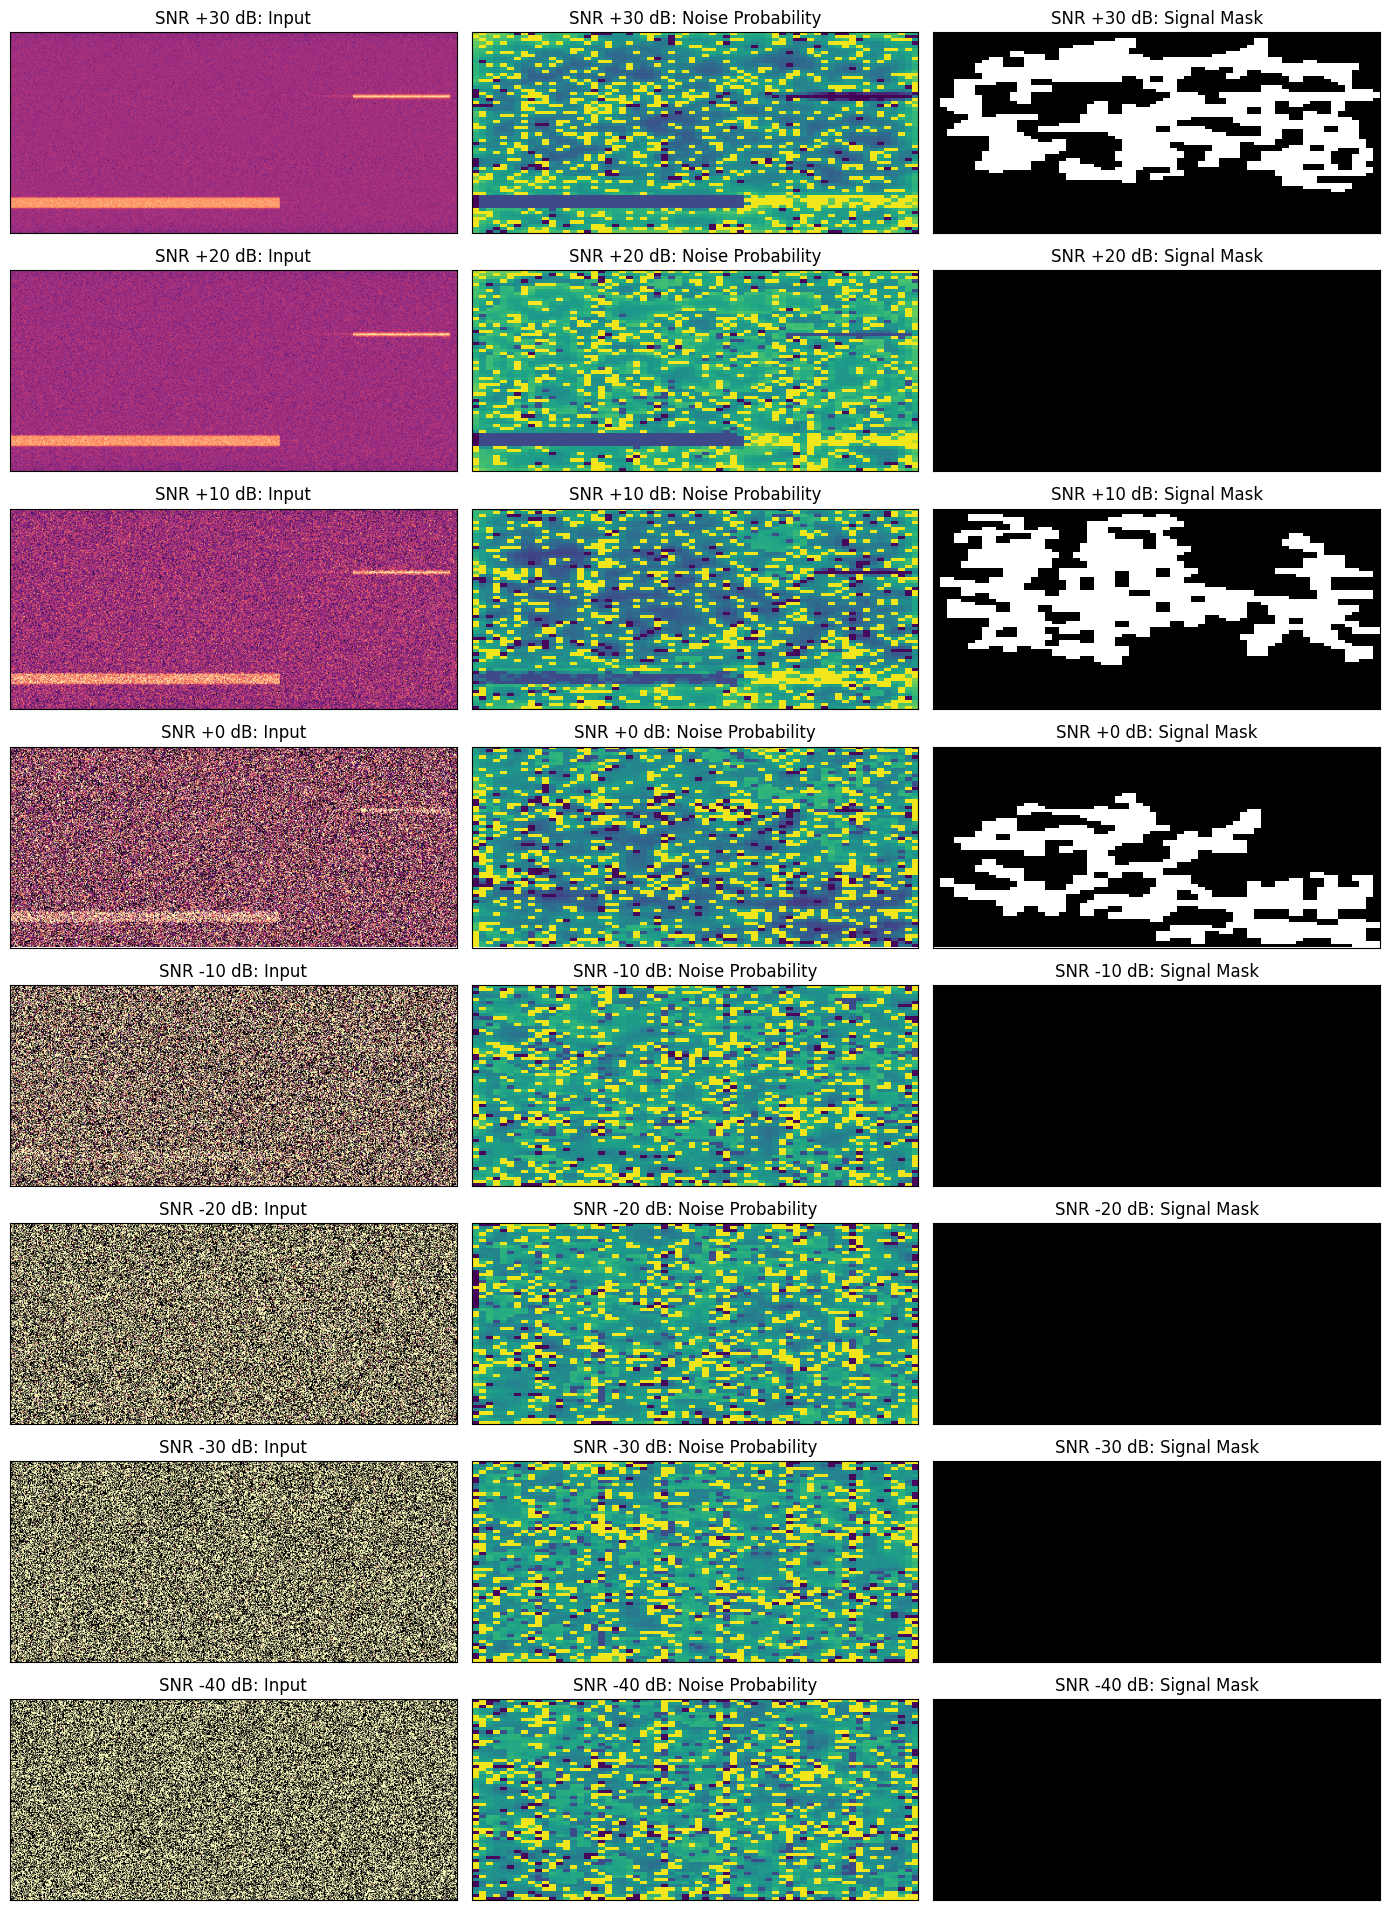

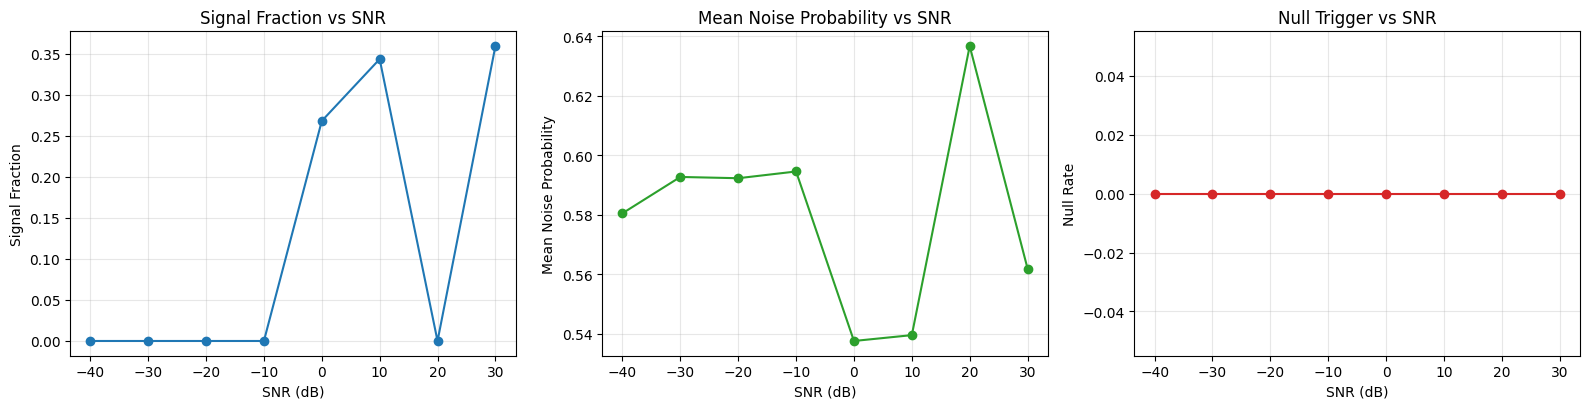

In [37]:
# V1-style real-file SNR sweep (single SIGMF capture from test_data using V2 detector)
# Select one SIGMF file, inject AWGN at multiple SNR levels, and plot per-level outputs.
from scipy import signal
import json

REAL_SWEEP_SNR_DB = [30, 20, 10, 0, -10, -20, -30, -40]
REAL_SWEEP_PATCH_HW = (64, 64)
REAL_SWEEP_META_INDEX = 0  # Change this to try different files in test_data.

# Persistence constraints requested for robust, non-real-data-specific filtering.
REAL_MIN_DURATION_US = 625.0
REAL_MIN_BANDWIDTH_KHZ = 25.0
REAL_PERSISTENCE_NOISE_BOOST = 0.22

real_test_data_dir = Path('/home/sat3737/holoscan_demo_workspace/test_data')
real_meta_files = sorted(real_test_data_dir.glob('*.sigmf-meta'))
if not real_meta_files:
    raise FileNotFoundError('No .sigmf-meta files found in test_data')

if REAL_SWEEP_META_INDEX < 0 or REAL_SWEEP_META_INDEX >= len(real_meta_files):
    raise IndexError(f'REAL_SWEEP_META_INDEX={REAL_SWEEP_META_INDEX} out of range [0, {len(real_meta_files)-1}]')

real_meta_path = real_meta_files[REAL_SWEEP_META_INDEX]
real_data_path = real_meta_path.with_suffix('').with_suffix('.sigmf-data')
if not real_data_path.exists():
    raise FileNotFoundError(f'Missing SIGMF data file: {real_data_path}')

with open(real_meta_path, 'r', encoding='utf-8') as f:
    real_meta = json.load(f)

real_datatype = real_meta.get('global', {}).get('core:datatype', 'ci16_le')
real_sample_rate = float(real_meta.get('global', {}).get('core:sample_rate', 20e6))
if real_datatype != 'ci16_le':
    raise ValueError(f'Unsupported datatype for this sweep: {real_datatype} (expected ci16_le)')

# Keep IQ load bounded for practical runtime.
REAL_MAX_IQ_SAMPLES = 2_000_000
real_iq_i16 = np.fromfile(real_data_path, dtype=np.int16, count=2 * REAL_MAX_IQ_SAMPLES)
if real_iq_i16.size < 2:
    raise ValueError('SIGMF data file is empty or unreadable.')

real_iq_pairs = real_iq_i16.reshape(-1, 2).astype(np.float32)
real_iq = real_iq_pairs[:, 0] + 1j * real_iq_pairs[:, 1]

real_nperseg = 1024
real_noverlap = 768
_, _, real_sxx = signal.spectrogram(
    real_iq,
    fs=real_sample_rate,
    nperseg=real_nperseg,
    noverlap=real_noverlap,
    return_onesided=False,
    mode='magnitude',
)
real_sxx = np.fft.fftshift(real_sxx, axes=0)
real_clean_db = 20.0 * np.log10(real_sxx + 1e-10)
real_clean_db = ndimage.zoom(
    real_clean_db,
    (256 / real_clean_db.shape[0], 512 / real_clean_db.shape[1]),
    order=1,
).astype(np.float32)

def _add_awgn_norm_db(sxx_db: np.ndarray, target_snr_db: float, rng: np.random.Generator) -> np.ndarray:
    db_min = float(sxx_db.min())
    db_max = float(sxx_db.max())
    db_range = max(db_max - db_min, 1e-8)
    x = (sxx_db - db_min) / db_range
    sig_rms = np.sqrt(np.mean(x ** 2) + 1e-12)
    noise_std = sig_rms / (10.0 ** (target_snr_db / 20.0))
    noise = rng.normal(0.0, noise_std, size=x.shape).astype(np.float32)
    x_noisy = np.clip(x + noise, 0.0, 1.0)
    return x_noisy * db_range + db_min

real_rng = np.random.default_rng(2026)
real_ph, real_pw = REAL_SWEEP_PATCH_HW
real_examples_v1_style = {}
real_rows_v1_style = []

for snr_db in REAL_SWEEP_SNR_DB:
    noisy_db = _add_awgn_norm_db(real_clean_db, snr_db, real_rng)
    out = detect_v2(
        noisy_db,
        real_ph,
        real_pw,
        prev_noise_prob=None,
        calib_profile=None,
        sample_rate_hz=real_sample_rate,
        nperseg=real_nperseg,
        noverlap=real_noverlap,
        min_duration_us=REAL_MIN_DURATION_US,
        min_bandwidth_khz=REAL_MIN_BANDWIDTH_KHZ,
        persistence_noise_boost=REAL_PERSISTENCE_NOISE_BOOST,
    )

    signal_mask = out['signal_mask']
    noise_prob = out['noise_prob']

    real_rows_v1_style.append({
        'snr_db': snr_db,
        'signal_frac': float(signal_mask.mean()),
        'signal_conf': float((1.0 - noise_prob[signal_mask > 0]).mean()) if signal_mask.sum() > 0 else 0.0,
        'null': float(out['null']),
        'noise_prob_mean': float(noise_prob.mean()),
        'gmm_gap': float(out['gmm_mean_gap']),
        'min_time_patches': int(out['min_time_patches']),
        'min_freq_patches': int(out['min_freq_patches']),
        'kept_cc': int(out['persistence_kept_cc']),
        'removed_cc': int(out['persistence_removed_cc']),
    })

    real_examples_v1_style[snr_db] = {
        'input_db': noisy_db,
        'noise_prob': noise_prob,
        'signal_mask': signal_mask,
    }

real_summary_v1_style = pd.DataFrame(real_rows_v1_style).sort_values('snr_db', ascending=False).reset_index(drop=True)
print(f'SIGMF meta: {real_meta_path}')
print(f'SIGMF data: {real_data_path}')
print(
    f'Persistence: min_duration={REAL_MIN_DURATION_US:.0f} us, '
    f'min_bandwidth={REAL_MIN_BANDWIDTH_KHZ:.1f} kHz, '
    f'noise_boost={REAL_PERSISTENCE_NOISE_BOOST:.2f}'
)
display(real_summary_v1_style)

# Per-SNR panel: Input + Noise Probability + Signal Mask
fig, axes = plt.subplots(len(REAL_SWEEP_SNR_DB), 3, figsize=(14, max(3, 2.4 * len(REAL_SWEEP_SNR_DB))))
if len(REAL_SWEEP_SNR_DB) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, snr_db in enumerate(REAL_SWEEP_SNR_DB):
    ex = real_examples_v1_style[snr_db]

    axes[r, 0].imshow(minmax(ex['input_db']), aspect='auto', cmap='magma')
    axes[r, 0].set_title(f'SNR {snr_db:+} dB: Input')

    axes[r, 1].imshow(ex['noise_prob'], aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[r, 1].set_title(f'SNR {snr_db:+} dB: Noise Probability')

    axes[r, 2].imshow(ex['signal_mask'], aspect='auto', cmap='gray', vmin=0, vmax=1)
    axes[r, 2].set_title(f'SNR {snr_db:+} dB: Signal Mask')

    for c in range(3):
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

plt.tight_layout()
plt.show()

# Compact SNR summary curves.
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
x = real_summary_v1_style['snr_db'].values

ax[0].plot(x, real_summary_v1_style['signal_frac'], marker='o')
ax[0].set_title('Signal Fraction vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('Signal Fraction')
ax[0].grid(True, alpha=0.3)

ax[1].plot(x, real_summary_v1_style['noise_prob_mean'], marker='o', color='tab:green')
ax[1].set_title('Mean Noise Probability vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('Mean Noise Probability')
ax[1].grid(True, alpha=0.3)

ax[2].plot(x, real_summary_v1_style['null'], marker='o', color='tab:red')
ax[2].set_title('Null Trigger vs SNR')
ax[2].set_xlabel('SNR (dB)')
ax[2].set_ylabel('Null Rate')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Real DINOv3 Integration Notes

This notebook now uses real DINOv3 patch embeddings with the same model/weights pattern as the original notebook.

If you want to switch backbone/weights:
1. Update MODEL_NAME and WEIGHTS_PATH in Cell 3.
2. Keep ph and pw consistent with your desired patch grid.
3. Re-run the sweep cell and the per-SNR visualization cell.
4. Compare summary metrics and per-SNR masks before changing fusion weights.